# Dataset Preparation

## 1. Imports and setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from allensdk.brain_observatory.ecephys.ecephys_project_api import EcephysProjectWarehouseApi
from allensdk.brain_observatory.ecephys.ecephys_project_api.rma_engine import RmaEngine

C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\pynwb\__init__.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_directory = "./ecephys_cache_dir"
manifest_path = os.path.join(data_directory, "manifest.json")

cache = EcephysProjectCache(
    manifest=manifest_path,
    fetch_api=EcephysProjectWarehouseApi(
        RmaEngine(
            scheme="http",
            host="api.brain-map.org",
            timeout=5 * 3600,
        )
    ),
)

SESSION_ID = 757216464
session = cache.get_session_data(SESSION_ID)


C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


### metadata check

In [3]:
session.metadata

C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
C:\Users\neo\miniconda3\envs\allen216\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.5.

{'specimen_name': 'C57BL/6J-412794',
 'session_type': 'brain_observatory_1.1',
 'full_genotype': 'wt/wt',
 'sex': 'M',
 'age_in_days': 105.0,
 'rig_equipment_name': 'NP.1',
 'num_units': 959,
 'num_channels': 2225,
 'num_probes': 6,
 'num_stimulus_presentations': 70390,
 'session_start_time': datetime.datetime(2018, 10, 26, 12, 55, 34, tzinfo=tzoffset(None, -25200)),
 'ecephys_session_id': 757216464,
 'structure_acronyms': [nan,
  'PO',
  'LP',
  'LGd',
  'HPF',
  'CA3',
  'DG',
  'CA1',
  'VISal',
  'VISrl',
  'VISl',
  'TH',
  'LGv',
  'MRN',
  'MB',
  'APN',
  'NOT',
  'VISam',
  'VIS',
  'Eth',
  'MGm',
  'SGN',
  'ProS',
  'SUB',
  'VISp'],
 'stimulus_names': ['spontaneous',
  'gabors',
  'flashes',
  'drifting_gratings',
  'natural_movie_three',
  'natural_movie_one',
  'static_gratings',
  'natural_scenes']}

In [4]:
session.structurewise_unit_counts

LP       114
CA1      112
VISp      85
PO        80
VISam     64
VIS       60
VISal     53
VISl      53
APN       47
SGN       45
Eth       42
DG        42
SUB       41
VISrl     37
TH        18
MGm       16
CA3       13
LGv       11
ProS       7
LGd        6
NOT        5
MRN        5
MB         3
Name: ecephys_structure_acronym, dtype: int64

## 3. Get image labels

In [5]:
presentations = session.stimulus_presentations
mask = (presentations["stimulus_name"] == "natural_scenes") & (presentations["frame"] != -1)
natural_scene_presentations = presentations.loc[mask]

labels = sorted(int(f) for f in natural_scene_presentations["frame"].unique())
assert len(labels) == 118, f"Found {len(labels)} labels"


## 4. Download the stimulus images

Each image is fetched via `cache.get_natural_scene_template(frame)`.

In [6]:
IMAGE_DIR = os.path.join(data_directory, "natural_scene_templates")
os.makedirs(IMAGE_DIR, exist_ok=True)

image_names = []
for frame in labels:
    img_array = cache.get_natural_scene_template(frame)
    img_name = f"natural_scene_{frame}"
    Image.fromarray(img_array).save(os.path.join(IMAGE_DIR, f"{img_name}.png"))
    image_names.append(img_name)

print(f"Saved {len(image_names)} images to {IMAGE_DIR}")


Saved 118 images to ./ecephys_cache_dir\natural_scene_templates


## 5. Save the image-name ↔ label mapping

This mapping is reused in every later notebook to keep image ordering consistent between the network activations and the neural firing-rate data.

In [7]:
labels_df = pd.DataFrame({
    "image_name": image_names,
    "frame": labels,
})
labels_df.to_csv("image_labels.csv", index=False)
labels_df.head()


,image_name,frame
0,natural_scene_0,0
1,natural_scene_1,1
2,natural_scene_2,2
3,natural_scene_3,3
4,natural_scene_4,4


## 6. Quick visual check

Sanity check: display a handful of the downloaded images.

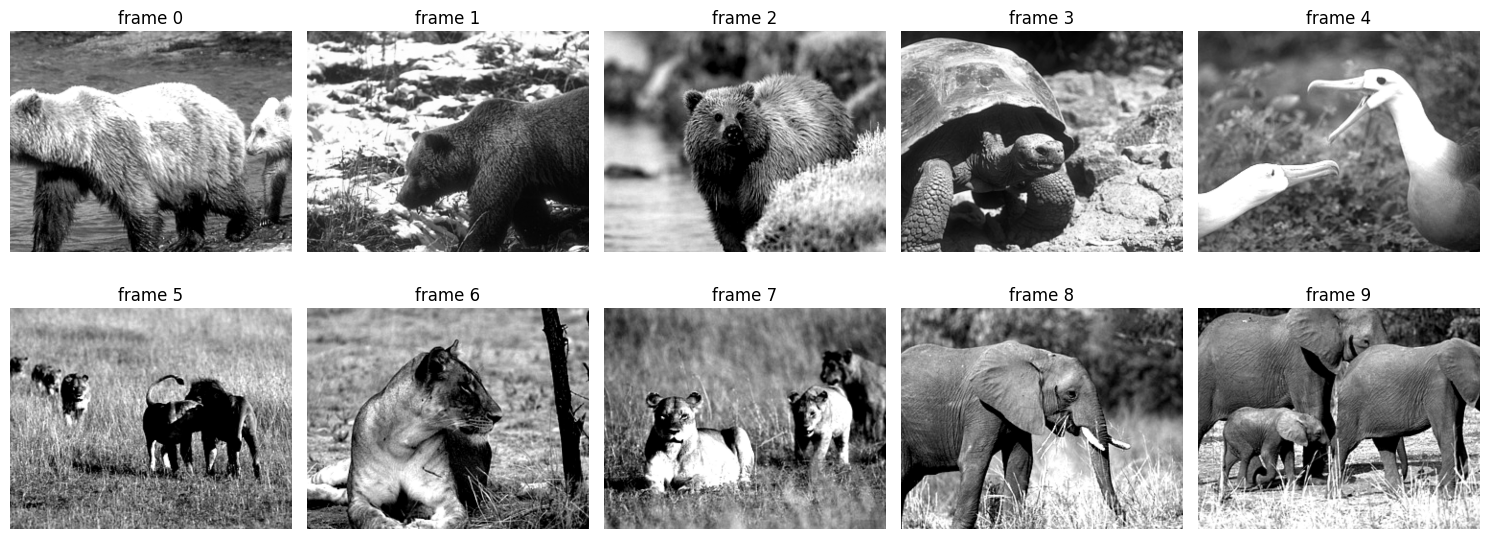

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_frames = labels[:10]

for ax, frame in zip(axes.flat, sample_frames):
    img = cache.get_natural_scene_template(frame)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"frame {frame}")
    ax.axis("off")

plt.tight_layout()
plt.show()
